<a href="https://colab.research.google.com/github/khanbaba-ahamaliiev/ITStep-AI/blob/superwised_learning/Practice_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [3]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
from sklearn.model_selection import train_test_split

In [6]:
y = df['price']
X = df.drop('price', axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(3808, 5) (3808,)
(952, 5) (952,)


# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [7]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model.predict(x_test)

array([12174., 22056., 14109., 23347., 31166., 20913.,  5406., 13758.,
       20140., 20687., 12221., 16694., 11015., 14025., 17738., 14891.,
       23165., 24523.,  9824., 16098., 14998., 16427., 16067., 19026.,
       18817., 14595., 25273., 18541., 22981., 25302.,  7474., 18154.,
       20975., 19352.,  1500., 14840., 25022., 23571., 23718., 17085.,
        6900., 12230.,  6827.,  8388., 12069., 13781.,  4280., 22159.,
       20772., 13831., 15579., 23063., 13758., 19656.,  1500., 19365.,
        5790., 12065., 16636., 16235., 14740., 17793., 17739., 19142.,
       12578.,  2704., 29101., 15996., 21107., 11665., 16132., 11103.,
       17432., 18394., 25467., 19159., 13224., 19760., 11768., 16582.,
       15413., 22135.,  5984., 22396., 14808., 27272., 27791., 22438.,
       12731., 19154., 13798., 23256., 15069., 13053., 20454., 24389.,
       10123., 15163., 18000., 11251., 19855., 17233., 25610., 14097.,
       15057., 12220., 11189., 16536., 24326.,  3604., 24503., 20705.,
      

In [22]:
pred = model.predict(x_test)

print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("R2: ", r2_score(y_test, pred))

MAE:  2998.8025210084033
MSE:  13968380.00840336
R2:  0.5516342051885796


In [21]:
pred = model.predict(x_train)

print("MAE: ", mean_absolute_error(y_train, pred))
print("MSE: ", mean_squared_error(y_train, pred))
print("R2: ", r2_score(y_train, pred))

MAE:  0.0
MSE:  0.0
R2:  1.0


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

In [33]:
train_mae = []
test_mae = []
max_depths = range(2,15)

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_mae.append(mean_absolute_error(y_train, train_pred))
    test_mae.append(mean_absolute_error(y_test, test_pred))
    print(f"Depth: {depth}, Train MAE: {train_mae[-1]}, Test MAE: {test_mae[-1]}")


Depth: 2, Train MAE: 3370.675497242045, Test MAE: 3276.1329386307693
Depth: 3, Train MAE: 2923.2265611961425, Test MAE: 2841.451556037191
Depth: 4, Train MAE: 2616.6429313246977, Test MAE: 2582.0253313989588
Depth: 5, Train MAE: 2428.453729478045, Test MAE: 2434.323528219818
Depth: 6, Train MAE: 2267.9994315482454, Test MAE: 2371.0694897265494
Depth: 7, Train MAE: 2094.89873852778, Test MAE: 2352.27925233386
Depth: 8, Train MAE: 1917.0353092929756, Test MAE: 2325.9501899467446
Depth: 9, Train MAE: 1729.781981722951, Test MAE: 2330.0965144852044
Depth: 10, Train MAE: 1521.077540852346, Test MAE: 2450.7870305497054
Depth: 11, Train MAE: 1290.4022395306245, Test MAE: 2611.1141735122696
Depth: 12, Train MAE: 1059.5364874169975, Test MAE: 2657.871793615977
Depth: 13, Train MAE: 844.2458808274205, Test MAE: 2719.4451260901774
Depth: 14, Train MAE: 655.211186239721, Test MAE: 2856.767596751482


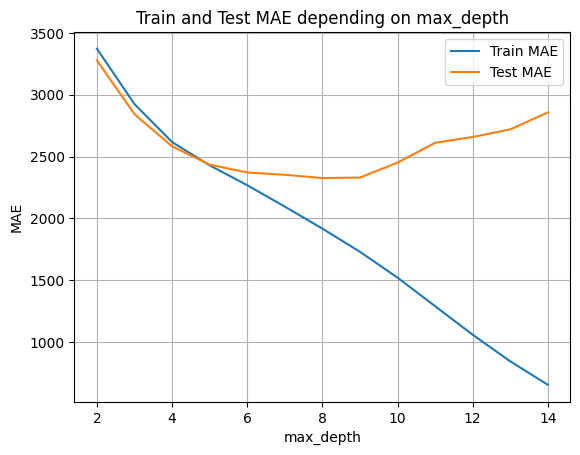

In [34]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

In [46]:
train_mse = []
test_mse = []
max_depths = range(2,15)

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_mse.append(mean_squared_error(y_train, train_pred))
    test_mse.append(mean_squared_error(y_test, test_pred))
    print(f"Depth: {depth}, Train MSE: {train_mse[-1]}, Test MSE: {test_mse[-1]}")


Depth: 2, Train MSE: 17497756.639697827, Test MSE: 16409452.185000427
Depth: 3, Train MSE: 13298249.738738332, Test MSE: 12869443.875461118
Depth: 4, Train MSE: 10725884.058365183, Test MSE: 10411550.874377279
Depth: 5, Train MSE: 9309938.371494608, Test MSE: 9395824.679634908
Depth: 6, Train MSE: 8115165.110174416, Test MSE: 8897367.454212854
Depth: 7, Train MSE: 7044595.578268086, Test MSE: 8847134.749930575
Depth: 8, Train MSE: 6088536.7460520705, Test MSE: 8639808.091652265
Depth: 9, Train MSE: 5120751.13195015, Test MSE: 8699201.97739866
Depth: 10, Train MSE: 4214563.275812559, Test MSE: 9764942.489500746
Depth: 11, Train MSE: 3382658.5915845726, Test MSE: 10368594.776268087
Depth: 12, Train MSE: 2605928.9313857593, Test MSE: 11231027.315413851
Depth: 13, Train MSE: 1978050.16209465, Test MSE: 11791361.14144863
Depth: 14, Train MSE: 1442453.9706945585, Test MSE: 12718158.07988961


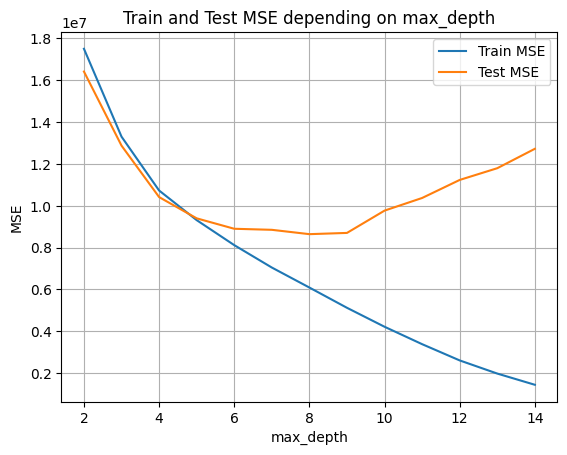

In [47]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")

plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [48]:
train_r2 = []
test_r2 = []
max_depths = range(2,15)

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_r2.append(r2_score(y_train, train_pred))
    test_r2.append(r2_score(y_test, test_pred))
    print(f"Depth: {depth}, Train r2: {train_r2[-1]}, Test r2: {test_r2[-1]}")

Depth: 2, Train r2: 0.460629312153503, Test r2: 0.4732791442585691
Depth: 3, Train r2: 0.5900796738443117, Test r2: 0.5869085442599118
Depth: 4, Train r2: 0.6693731898638344, Test r2: 0.6658035305310042
Depth: 5, Train r2: 0.7130199049717576, Test r2: 0.698406944981532
Depth: 6, Train r2: 0.7498489504916181, Test r2: 0.7151974962602364
Depth: 7, Train r2: 0.7828493994464159, Test r2: 0.7156620638268334
Depth: 8, Train r2: 0.8123200407733245, Test r2: 0.7225520134554699
Depth: 9, Train r2: 0.8421521617197222, Test r2: 0.7137335286741635
Depth: 10, Train r2: 0.8700855235413274, Test r2: 0.6860790900125951
Depth: 11, Train r2: 0.8957290966572534, Test r2: 0.6649098570764536
Depth: 12, Train r2: 0.9196718922806497, Test r2: 0.6318389920543593
Depth: 13, Train r2: 0.9390263392906412, Test r2: 0.624039546621086
Depth: 14, Train r2: 0.9555361634990787, Test r2: 0.6037040324212366


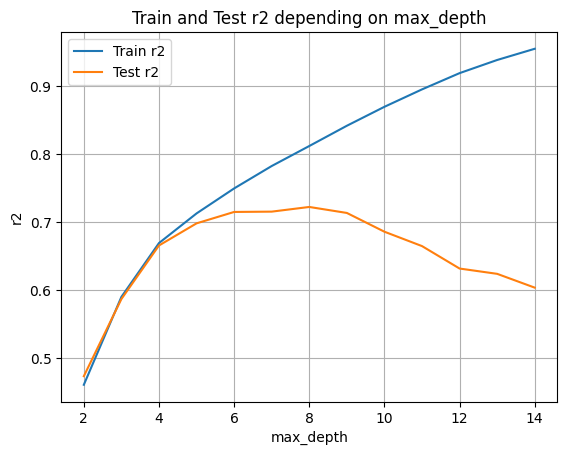

In [49]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_r2, label="Train r2")
plt.plot(max_depths, test_r2, label="Test r2")

plt.xlabel("max_depth")
plt.ylabel("r2")
plt.title("Train and Test r2 depending on max_depth")
plt.legend()
plt.grid()

plt.show()